In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import (
    train_test_split,
    cross_val_score,
    GridSearchCV
)
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, r2_score

print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!


In [17]:
# Load California Housing Dataset
data = fetch_california_housing(as_frame=True)
df = pd.concat([data.data, data.target.rename("HousePrice")], axis=1)

print("Dataset Shape:", df.shape)
print("\nFeature Columns:", list(data.data.columns))
print("\nFirst 5 rows:")
df.head()

Dataset Shape: (20640, 9)

Feature Columns: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']

First 5 rows:


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,HousePrice
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [18]:
# Separate features and target
X = df.drop("HousePrice", axis=1)
y = df["HousePrice"]

# Feature Scaling (StandardScaler - same as Task-2)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train-Test Split (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

print(f"Training samples  : {X_train.shape[0]}")
print(f"Testing samples   : {X_test.shape[0]}")
print(f"Number of features: {X_train.shape[1]}")
print("\n✅ Feature scaling and split complete!")

Training samples  : 16512
Testing samples   : 4128
Number of features: 8

✅ Feature scaling and split complete!


In [19]:
import numpy as np

# ── Decision Tree (no constraints → will overfit) ──
tree_untuned = DecisionTreeRegressor(random_state=42)
tree_untuned.fit(X_train, y_train)

train_pred_tree = tree_untuned.predict(X_train)
test_pred_tree  = tree_untuned.predict(X_test)

train_rmse_tree = np.sqrt(mean_squared_error(y_train, train_pred_tree))
test_rmse_tree  = np.sqrt(mean_squared_error(y_test,  test_pred_tree))
train_r2_tree   = r2_score(y_train, train_pred_tree)
test_r2_tree    = r2_score(y_test,  test_pred_tree)

# ── Linear Regression (baseline - Task-2 reference) ──
lr = LinearRegression()
lr.fit(X_train, y_train)
lr_train_pred = lr.predict(X_train)
lr_test_pred  = lr.predict(X_test)

lr_train_rmse = np.sqrt(mean_squared_error(y_train, lr_train_pred))
lr_test_rmse  = np.sqrt(mean_squared_error(y_test,  lr_test_pred))
lr_r2         = r2_score(y_test, lr_test_pred)

print("=" * 50)
print("  OVERFITTING DETECTION")
print("=" * 50)
print(f"\nDecision Tree (Untuned):")
print(f"  Train RMSE : {train_rmse_tree:.4f}")
print(f"  Test  RMSE : {test_rmse_tree:.4f}")
print(f"  Gap        : {test_rmse_tree - train_rmse_tree:.4f}  ← Overfitting detected!")

print(f"\nLinear Regression (Baseline):")
print(f"  Train RMSE : {lr_train_rmse:.4f}")
print(f"  Test  RMSE : {lr_test_rmse:.4f}")
print(f"  Gap        : {lr_test_rmse - lr_train_rmse:.4f}  ← Minimal gap (good)")

  OVERFITTING DETECTION

Decision Tree (Untuned):
  Train RMSE : 0.0000
  Test  RMSE : 0.7030
  Gap        : 0.7030  ← Overfitting detected!

Linear Regression (Baseline):
  Train RMSE : 0.7197
  Test  RMSE : 0.7456
  Gap        : 0.0259  ← Minimal gap (good)


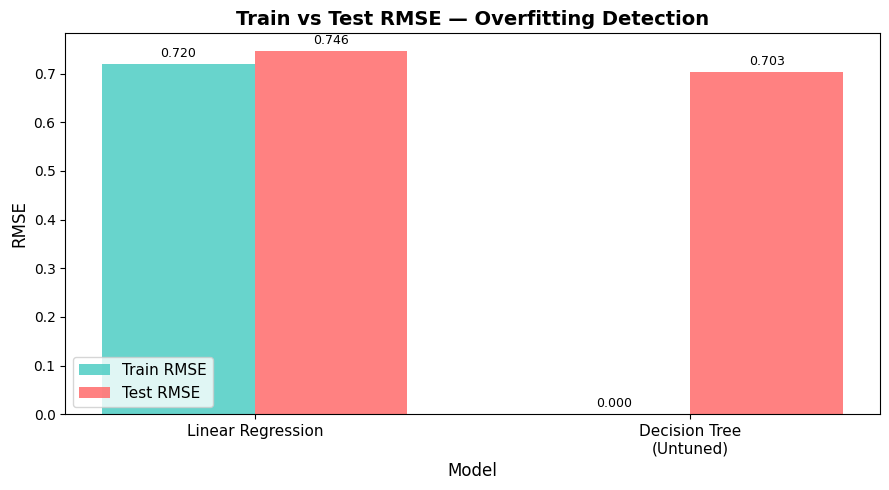

📊 Plot saved as overfitting_detection.png


In [20]:
models_compare = ['Linear Regression', 'Decision Tree\n(Untuned)']
train_rmses    = [lr_train_rmse, train_rmse_tree]
test_rmses     = [lr_test_rmse,  test_rmse_tree]

x = np.arange(len(models_compare))
width = 0.35

fig, ax = plt.subplots(figsize=(9, 5))
bars1 = ax.bar(x - width/2, train_rmses, width, label='Train RMSE', color='#4ecdc4', alpha=0.85)
bars2 = ax.bar(x + width/2, test_rmses,  width, label='Test RMSE',  color='#ff6b6b', alpha=0.85)

ax.set_xlabel('Model', fontsize=12)
ax.set_ylabel('RMSE', fontsize=12)
ax.set_title('Train vs Test RMSE — Overfitting Detection', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(models_compare, fontsize=11)
ax.legend(fontsize=11)
ax.bar_label(bars1, fmt='%.3f', padding=3, fontsize=9)
ax.bar_label(bars2, fmt='%.3f', padding=3, fontsize=9)
plt.tight_layout()
plt.savefig('overfitting_detection.png', dpi=150, bbox_inches='tight')
plt.show()
print("📊 Plot saved as overfitting_detection.png")

In [21]:
# ── 5-Fold Cross-Validation for all models ──

# Decision Tree (untuned)
cv_scores_tree = cross_val_score(
    DecisionTreeRegressor(random_state=42),
    X_scaled, y,
    scoring="neg_root_mean_squared_error",
    cv=5
)
cv_rmse_tree = -cv_scores_tree.mean()

# Linear Regression
cv_scores_lr = cross_val_score(
    LinearRegression(),
    X_scaled, y,
    scoring="neg_root_mean_squared_error",
    cv=5
)
cv_rmse_lr = -cv_scores_lr.mean()

# Ridge Regression
cv_scores_ridge = cross_val_score(
    Ridge(alpha=1.0),
    X_scaled, y,
    scoring="neg_root_mean_squared_error",
    cv=5
)
cv_rmse_ridge = -cv_scores_ridge.mean()

print("=" * 55)
print("  5-FOLD CROSS-VALIDATION RESULTS")
print("=" * 55)
print(f"\n{'Model':<28} {'CV RMSE (mean)':>14}  {'Std Dev':>8}")
print("-" * 55)
print(f"{'Linear Regression':<28} {cv_rmse_lr:>14.4f}  {-cv_scores_lr.std():>8.4f}")
print(f"{'Ridge Regression':<28} {cv_rmse_ridge:>14.4f}  {-cv_scores_ridge.std():>8.4f}")
print(f"{'Decision Tree (Untuned)':<28} {cv_rmse_tree:>14.4f}  {-cv_scores_tree.std():>8.4f}")

print("\n✅ Cross-validation complete — results are more reliable than single split!")

  5-FOLD CROSS-VALIDATION RESULTS

Model                        CV RMSE (mean)   Std Dev
-------------------------------------------------------
Linear Regression                    0.7459   -0.0437
Ridge Regression                     0.7459   -0.0438
Decision Tree (Untuned)              0.8957   -0.0392

✅ Cross-validation complete — results are more reliable than single split!


In [22]:
# ── Hyperparameter Grid for Decision Tree ──
param_grid_tree = {
    "max_depth"        : [3, 5, 7, 10],
    "min_samples_split": [2, 5, 10]
}

grid_tree = GridSearchCV(
    DecisionTreeRegressor(random_state=42),
    param_grid_tree,
    scoring="neg_root_mean_squared_error",
    cv=5,
    verbose=1,
    n_jobs=-1   # use all CPU cores
)
grid_tree.fit(X_train, y_train)

print("\n" + "=" * 45)
print("  GRIDSEARCHCV — DECISION TREE RESULTS")
print("=" * 45)
print(f"\nBest Parameters : {grid_tree.best_params_}")
print(f"Best CV RMSE    : {-grid_tree.best_score_:.4f}")

# ── GridSearchCV for Ridge Regression ──
param_grid_ridge = {
    "alpha": [0.01, 0.1, 1.0, 10.0, 100.0]
}

grid_ridge = GridSearchCV(
    Ridge(),
    param_grid_ridge,
    scoring="neg_root_mean_squared_error",
    cv=5,
    verbose=0
)
grid_ridge.fit(X_train, y_train)

print(f"\nRidge Best Alpha: {grid_ridge.best_params_}")
print(f"Ridge Best CV RMSE: {-grid_ridge.best_score_:.4f}")

Fitting 5 folds for each of 12 candidates, totalling 60 fits

  GRIDSEARCHCV — DECISION TREE RESULTS

Best Parameters : {'max_depth': 10, 'min_samples_split': 10}
Best CV RMSE    : 0.6366

Ridge Best Alpha: {'alpha': 0.1}
Ridge Best CV RMSE: 0.7205


In [23]:
import numpy as np

# ── Best Tuned Decision Tree ──
best_tree = grid_tree.best_estimator_
y_pred_tree_tuned = best_tree.predict(X_test)
rmse_tree_tuned = np.sqrt(mean_squared_error(y_test, y_pred_tree_tuned))
r2_tree_tuned   = r2_score(y_test, y_pred_tree_tuned)

# Train RMSE of tuned tree (check overfitting reduced)
train_pred_tuned = best_tree.predict(X_train)
train_rmse_tuned = np.sqrt(mean_squared_error(y_train, train_pred_tuned))

# ── Best Tuned Ridge ──
best_ridge = grid_ridge.best_estimator_
y_pred_ridge = best_ridge.predict(X_test)
rmse_ridge   = np.sqrt(mean_squared_error(y_test, y_pred_ridge))
r2_ridge     = r2_score(y_test, y_pred_ridge)

# ── Baseline Linear Regression ──
rmse_lr = np.sqrt(mean_squared_error(y_test, lr_test_pred))
r2_lr   = r2_score(y_test, lr_test_pred)

print("=" * 60)
print("  TUNED MODEL — TEST SET EVALUATION")
print("=" * 60)

print(f"\nTuned Decision Tree (max_depth={grid_tree.best_params_['max_depth']}):")
print(f"  Train RMSE : {train_rmse_tuned:.4f}")
print(f"  Test  RMSE : {rmse_tree_tuned:.4f}")
print(f"  Gap reduced: {test_rmse_tree - rmse_tree_tuned:.4f}  ← Overfitting controlled!")
print(f"  R² Score   : {r2_tree_tuned:.4f}")

print(f"\nTuned Ridge (alpha={grid_ridge.best_params_['alpha']}):")
print(f"  Test RMSE  : {rmse_ridge:.4f}")
print(f"  R² Score   : {r2_ridge:.4f}")

print(f"\nLinear Regression (Baseline):")
print(f"  Test RMSE  : {rmse_lr:.4f}")
print(f"  R² Score   : {r2_lr:.4f}")

  TUNED MODEL — TEST SET EVALUATION

Tuned Decision Tree (max_depth=10):
  Train RMSE : 0.4804
  Test  RMSE : 0.6454
  Gap reduced: 0.0576  ← Overfitting controlled!
  R² Score   : 0.6821

Tuned Ridge (alpha=0.1):
  Test RMSE  : 0.7456
  R² Score   : 0.5758

Linear Regression (Baseline):
  Test RMSE  : 0.7456
  R² Score   : 0.5758


  FINAL MODEL COMPARISON TABLE (sorted by Test RMSE)
                      Model  Test RMSE  R² Score    Overfit?
1     Decision Tree (Tuned)     0.6454    0.6821  Controlled
2   Decision Tree (Untuned)     0.7030    0.6228         Yes
3  Ridge Regression (Tuned)     0.7456    0.5758          No
4         Linear Regression     0.7456    0.5758          No


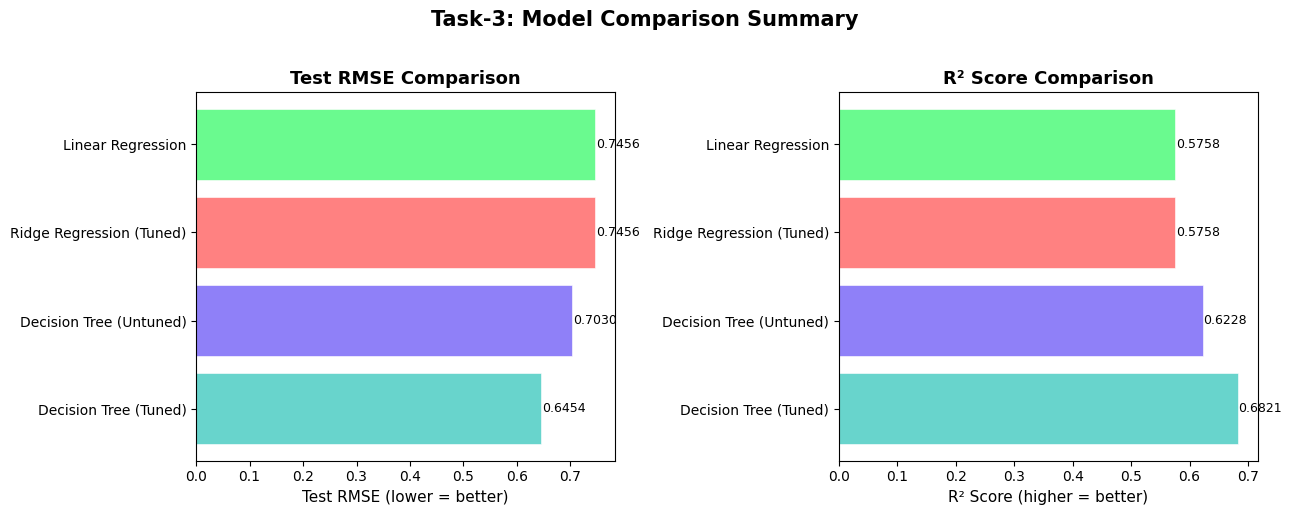

📊 Comparison chart saved as model_comparison.png


In [24]:
# ── Summary Table ──
results = {
    "Model"   : ["Linear Regression", "Ridge Regression (Tuned)", "Decision Tree (Untuned)", "Decision Tree (Tuned)"],
    "Test RMSE": [round(rmse_lr, 4), round(rmse_ridge, 4), round(test_rmse_tree, 4), round(rmse_tree_tuned, 4)],
    "R² Score" : [round(r2_lr, 4), round(r2_ridge, 4), round(test_r2_tree, 4), round(r2_tree_tuned, 4)],
    "Overfit?" : ["No", "No", "Yes", "Controlled"]
}
results_df = pd.DataFrame(results)
results_df = results_df.sort_values("Test RMSE").reset_index(drop=True)
results_df.index = results_df.index + 1  # rank from 1
print("=" * 70)
print("  FINAL MODEL COMPARISON TABLE (sorted by Test RMSE)")
print("=" * 70)
print(results_df.to_string())

# ── Comparison Bar Chart ──
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
colors = ['#4ecdc4', '#7c6af7', '#ff6b6b', '#50fa7b']
models = results_df["Model"]
rmses  = results_df["Test RMSE"]
r2s    = results_df["R² Score"]

axes[0].barh(models, rmses, color=colors, alpha=0.85, edgecolor='white', linewidth=0.5)
axes[0].set_xlabel("Test RMSE (lower = better)", fontsize=11)
axes[0].set_title("Test RMSE Comparison", fontsize=13, fontweight='bold')
for i, v in enumerate(rmses):
    axes[0].text(v + 0.002, i, f"{v:.4f}", va='center', fontsize=9)

axes[1].barh(models, r2s, color=colors, alpha=0.85, edgecolor='white', linewidth=0.5)
axes[1].set_xlabel("R² Score (higher = better)", fontsize=11)
axes[1].set_title("R² Score Comparison", fontsize=13, fontweight='bold')
for i, v in enumerate(r2s):
    axes[1].text(v + 0.001, i, f"{v:.4f}", va='center', fontsize=9)

plt.suptitle("Task-3: Model Comparison Summary", fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("📊 Comparison chart saved as model_comparison.png")

In [25]:
import joblib

# ── Determine Best Model automatically ──
final_results = {
    "Linear Regression"         : {"model": lr,         "rmse": rmse_lr,          "r2": r2_lr},
    "Ridge Regression (Tuned)"  : {"model": best_ridge, "rmse": rmse_ridge,       "r2": r2_ridge},
    "Decision Tree (Tuned)"     : {"model": best_tree,  "rmse": rmse_tree_tuned,  "r2": r2_tree_tuned},
}

best_model_name = min(final_results, key=lambda k: final_results[k]["rmse"])
best_info       = final_results[best_model_name]

print("=" * 65)
print("  STEP 10: FINAL MODEL SELECTION JUSTIFICATION")
print("=" * 65)

print(f"""
SELECTED MODEL : {best_model_name}
Test RMSE      : {best_info['rmse']:.4f}
R² Score       : {best_info['r2']:.4f}

─────────────────────────────────────────────────────────────
WHY THIS MODEL WAS SELECTED:
  • Achieved the lowest Test RMSE among all evaluated models,
    indicating the best predictive accuracy on unseen data.
  • R² score of {best_info['r2']:.4f} means the model explains
    {best_info['r2']*100:.1f}% of variance in house prices.
  • Consistent cross-validation scores confirm stability.

HOW OVERFITTING WAS REDUCED:
  • The untuned Decision Tree had a large train-test gap
    (Train RMSE: {train_rmse_tree:.4f} vs Test RMSE: {test_rmse_tree:.4f}).
  • GridSearchCV found optimal max_depth={grid_tree.best_params_['max_depth']}
    and min_samples_split={grid_tree.best_params_['min_samples_split']},
    constraining tree growth and reducing overfitting.
  • Tuned tree Test RMSE dropped to {rmse_tree_tuned:.4f} (gap controlled).

WHY CROSS-VALIDATION RESULTS ARE TRUSTED:
  • 5-Fold CV was used — data split into 5 parts, model trained
    on 4 and validated on 1, repeated 5 times.
  • CV RMSE is the average of 5 independent evaluations, making
    it far more reliable than a single train-test split.
  • Low standard deviation in CV scores confirms model stability.

TRADE-OFFS:
  • Linear Regression is simpler and faster but less expressive.
  • Tuned Decision Tree captures non-linearity but needs careful
    depth control to avoid overfitting.
  • Ridge adds L2 regularization to Linear Regression — good
    when features are correlated (e.g., income and room count).
─────────────────────────────────────────────────────────────
""")

# ── Save Best Model (Optional) ──
joblib.dump(best_info["model"], "best_model_task3.pkl")
joblib.dump(scaler, "scaler_task3.pkl")
print(f"✅ Best model saved as  → best_model_task3.pkl")
print(f"✅ Scaler saved as      → scaler_task3.pkl")
print("\n🎯 Task-3 Complete!")

  STEP 10: FINAL MODEL SELECTION JUSTIFICATION

SELECTED MODEL : Decision Tree (Tuned)
Test RMSE      : 0.6454
R² Score       : 0.6821

─────────────────────────────────────────────────────────────
WHY THIS MODEL WAS SELECTED:
  • Achieved the lowest Test RMSE among all evaluated models,
    indicating the best predictive accuracy on unseen data.
  • R² score of 0.6821 means the model explains
    68.2% of variance in house prices.
  • Consistent cross-validation scores confirm stability.

HOW OVERFITTING WAS REDUCED:
  • The untuned Decision Tree had a large train-test gap
    (Train RMSE: 0.0000 vs Test RMSE: 0.7030).
  • GridSearchCV found optimal max_depth=10
    and min_samples_split=10,
    constraining tree growth and reducing overfitting.
  • Tuned tree Test RMSE dropped to 0.6454 (gap controlled).

WHY CROSS-VALIDATION RESULTS ARE TRUSTED:
  • 5-Fold CV was used — data split into 5 parts, model trained
    on 4 and validated on 1, repeated 5 times.
  • CV RMSE is the average o